<a href="https://colab.research.google.com/github/TechWithEva/Telecom-X-Challenge3-G9/blob/main/TelecomX_Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECCION

# TELECOM X

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
URL=('https://raw.githubusercontent.com/TechWithEva/Telecom-X-Challenge3-G9/refs/heads/main/rawdata/base_ClientesTX.csv')
base_ClientesTX=pd.read_csv(URL)
ClientesTXBase = base_ClientesTX.copy()
ClientesTXBase['churn']=ClientesTXBase['churn'].astype(int)
ClientesTXBase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   clienteID                           7267 non-null   object 
 1   churn                               7267 non-null   int64  
 2   genero                              7267 non-null   object 
 3   tercera_edad                        7267 non-null   bool   
 4   tiene_pareja                        7267 non-null   bool   
 5   tiene_dependientes                  7267 non-null   bool   
 6   antiguedadContrato_Meses            7267 non-null   int64  
 7   telefono_suscripcion                7267 non-null   bool   
 8   telefono_lineas_multiples           7267 non-null   bool   
 9   internet_suscripcion                7267 non-null   bool   
 10  seguridadOnline_suscripcion         7267 non-null   bool   
 11  backupOnline_suscripcion            7267 no

## Depurar data
---
Eliminar columnas no necesarias para los modelos

In [65]:
ClientesTXBase.drop(columns=['clienteID'], inplace=True)

In [66]:
ClientesTXBase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   churn                               7267 non-null   int64  
 1   genero                              7267 non-null   object 
 2   tercera_edad                        7267 non-null   bool   
 3   tiene_pareja                        7267 non-null   bool   
 4   tiene_dependientes                  7267 non-null   bool   
 5   antiguedadContrato_Meses            7267 non-null   int64  
 6   telefono_suscripcion                7267 non-null   bool   
 7   telefono_lineas_multiples           7267 non-null   bool   
 8   internet_suscripcion                7267 non-null   bool   
 9   seguridadOnline_suscripcion         7267 non-null   bool   
 10  backupOnline_suscripcion            7267 non-null   bool   
 11  proteccionDispositivos_suscripcion  7267 no

## Correlación de variables númericas

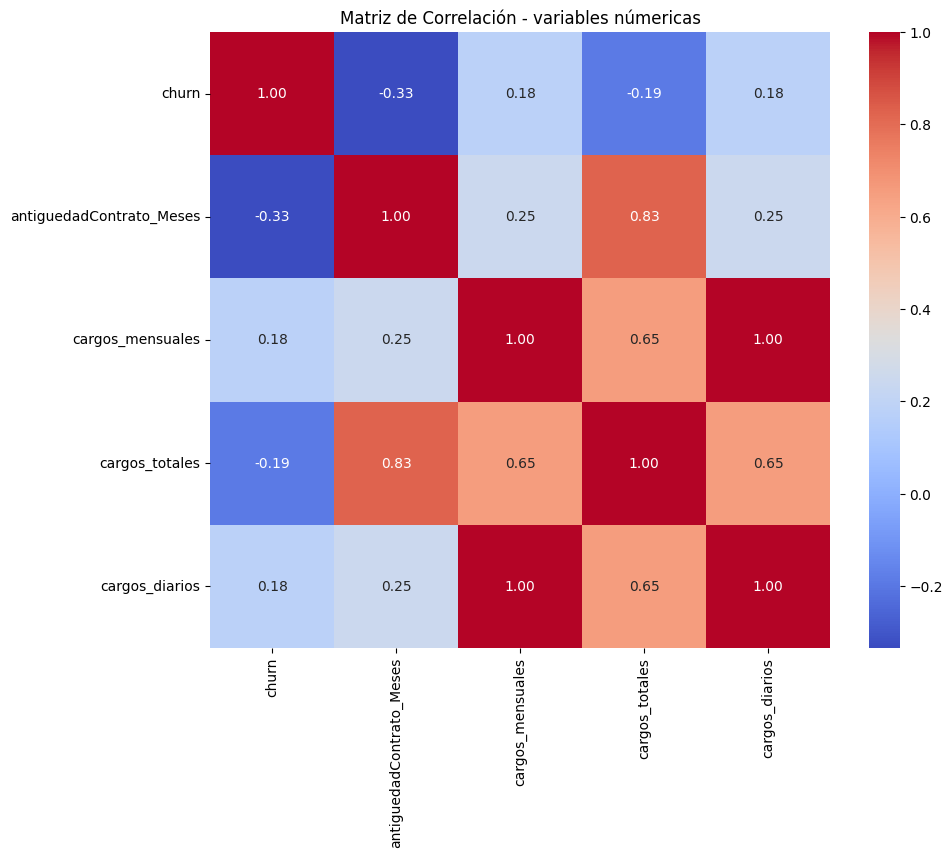

In [67]:
ClientesTXBaseNumeric = ClientesTXBase.select_dtypes(include=np.number)
matriz_correlacion = ClientesTXBaseNumeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - variables númericas')
plt.show()


In [68]:
#se eliminan variables que brindan la misma info
ClientesTXBase.drop(columns=['cargos_diarios','cargos_totales'], inplace=True)

# Análisis de Churn por categoría (variables categóricas)

In [69]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

df_rank = ClientesTXBase.copy()
columns_categorical = df_rank.select_dtypes(include=['object','bool']).columns
le = LabelEncoder()
for column in columns_categorical:
    df_rank[column] = le.fit_transform(df_rank[column])

xCat = df_rank[columns_categorical]
yCat = df_rank['churn']

chi2_scores, p_values = chi2(xCat, yCat)
chi_df = pd.DataFrame({'Variable':columns_categorical,'chi2_Score':chi2_scores,'p_value': p_values})
chi_df = chi_df.sort_values(by='chi2_Score', ascending=False)
chi_df


,Variable,chi2_Score,p_value
15,metodo_pago,440.553562,8.202947e-98
13,tipo_contrato,367.226879,7.516137e-82
16,pago_automatico,166.448214,4.415286e-38
7,seguridadOnline_suscripcion,140.282859,2.308657e-32
10,soporteTecnico_suscripcion,129.070531,6.545079e-30
1,tercera_edad,127.169623,1.705553e-29
3,tiene_dependientes,119.476204,8.237765e-28
14,factura_digital,100.704259,1.067957e-23
18,ambasSuscripciones,85.800085,1.990776e-20
2,tiene_pareja,72.207255,1.937421e-17


In [70]:
columns_categorical = ClientesTXBase.select_dtypes(include=['object','bool']).columns
columns_categorical

for column in columns_categorical:
  print(f'\n Análisis de Variables: {column}')
  display(pd.crosstab(ClientesTXBase[column], ClientesTXBase['churn'], normalize='index')*100)




 Análisis de Variables: genero


churn,0,1
genero,,
F,70.963252,29.036748
M,71.428571,28.571429



 Análisis de Variables: tercera_edad


churn,0,1
tercera_edad,,
False,74.083813,25.916187
True,56.345178,43.654822



 Análisis de Variables: tiene_pareja


...

churn,0,1
pago_automatico,,
False,63.211679,36.788321
True,81.596452,18.403548



 Análisis de Variables: tipo_servicio_internet


churn,0,1
tipo_servicio_internet,,
DSL,78.858521,21.141479
FIBRA OPTICA,56.253909,43.746091
SIN SUSCRIPCIÓN A INTERNET,89.373814,10.626186



 Análisis de Variables: ambasSuscripciones


churn,0,1
ambasSuscripciones,,
False,84.134615,15.865385
True,65.254067,34.745933
